In [91]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
!pip install -U "sympy<1.13"

In [93]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [94]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
        )

        self.relu = nn.ReLU(inplace=True)

        if in_channels != out_channels:
            self.residual = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual = nn.Identity()

    def forward(self, x):
        return self.relu(self.conv(x) + self.residual(x))

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.up_trans1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.up1 = DoubleConv(512, 256)

        self.up_trans2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up2 = DoubleConv(256, 128)

        self.up_trans3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up3 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))
        d4 = self.down4(self.pool(d3))

        x = self.up_trans1(d4)
        x = torch.cat([x, d3], dim=1)
        x = self.up1(x)

        x = self.up_trans2(x)
        x = torch.cat([x, d2], dim=1)
        x = self.up2(x)

        x = self.up_trans3(x)
        x = torch.cat([x, d1], dim=1)
        x = self.up3(x)

        return torch.sigmoid(self.out(x))

In [96]:
def clahe(img):
        img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(img)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        cl = clahe.apply(l)
        limg = cv2.merge((cl,a,b))
        return cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

class Dataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        green = image[:, :, 1]
        image = np.stack([green]*3, axis=-1)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (512, 512))
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)

        image = clahe(image)

        if np.random.rand() > 0.5:
            image = np.flip(image, axis=1).copy()
            mask  = np.flip(mask, axis=1).copy()

        if np.random.rand() > 0.5:
            image = np.flip(image, axis=0).copy()
            mask  = np.flip(mask, axis=0).copy()

        image = image / 255.0
        mask = (mask > 0).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [98]:
class PatchDataset(Dataset):
    def __init__(self, images, masks, patch_size=256, vessel_threshold=0.01):
        self.images = images
        self.masks = masks
        self.patch_size = patch_size
        self.vessel_threshold = vessel_threshold

    def __len__(self):
        return len(self.images) * 20

    def __getitem__(self, idx):
        img_idx = random.randint(0, len(self.images) - 1)

        image = self.images[img_idx]
        mask = self.masks[img_idx]

        _, H, W = mask.shape
        ps = self.patch_size

        for _ in range(10):
            x = random.randint(0, H - ps)
            y = random.randint(0, W - ps)

            img_patch = image[:, x:x+ps, y:y+ps]
            mask_patch = mask[:, x:x+ps, y:y+ps]

            if mask_patch.mean() > self.vessel_threshold:
                return img_patch, mask_patch

        return img_patch, mask_patch

In [97]:
from torch.utils.data import DataLoader

def preload_dataset(dataset, device="cpu"):
    images = []
    masks = []

    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    for img, mask in loader:
        images.append(img.squeeze(0))
        masks.append(mask.squeeze(0))

    return images, masks

In [99]:
from glob import glob

train_images = sorted(glob("/content/drive/MyDrive/DRIVE/training/images/*.tif"))
train_masks = sorted(glob("/content/drive/MyDrive/DRIVE/training/1st_manual/*.gif"))

print("Training images:", len(train_images))
print("Training masks:", len(train_masks))

train_img, val_img, train_mask, val_mask = train_test_split(
    train_images, train_masks, test_size=0.2, random_state=42
)

train_dataset = Dataset(train_img, train_mask)
train_images, train_masks = preload_dataset(train_dataset)
patch_dataset = PatchDataset(train_images, train_masks, patch_size=256, vessel_threshold=0.01)
train_loader = DataLoader(patch_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)

val_dataset = Dataset(val_img, val_mask)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

Training images: 20
Training masks: 20


In [95]:
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def soft_skeletonize(x, iters=10):
    for _ in range(iters):
        min_pool = -F.max_pool2d(-x, kernel_size=3, stride=1, padding=1)
        contour = F.relu(min_pool - x)
        x = F.relu(x - contour)
    return x

def cldice_loss(pred, target, smooth=1e-6):
    pred = pred.clamp(0, 1)
    skel_pred = soft_skeletonize(pred)
    skel_gt = soft_skeletonize(target)

    tprec = (skel_pred * target).sum() / (skel_pred.sum() + smooth)
    tsens = (skel_gt * pred).sum() / (skel_gt.sum() + smooth)

    cldice = (2 * tprec * tsens) / (tprec + tsens + smooth)
    return 1 - cldice

def combined_loss(pred, target):
    dice = dice_loss(pred, target)
    cld  = cldice_loss(pred, target)

    return 0.4 * dice + 0.6 * cld

def calculate_metrics(pred, target):
    pred = torch.sigmoid(pred) if pred.max() > 1 else pred
    pred = (pred > 0.5).float()

    TP = (pred * target).sum(dim=(1,2,3))
    FP = (pred * (1 - target)).sum(dim=(1,2,3))
    FN = ((1 - pred) * target).sum(dim=(1,2,3))
    TN = ((1 - pred) * (1 - target)).sum(dim=(1,2,3))

    dice = (2*TP) / (2*TP + FP + FN + 1e-6)
    iou = TP / (TP + FP + FN + 1e-6)
    sensitivity = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)

    return (
        dice.mean().item(),
        iou.mean().item(),
        sensitivity.mean().item(),
        specificity.mean().item()
    )

In [101]:
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

epochs = 40

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        loss = combined_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

Epoch [1/40] Loss: 0.6166
Epoch [2/40] Loss: 0.4222
Epoch [3/40] Loss: 0.3515
Epoch [4/40] Loss: 0.3112
Epoch [5/40] Loss: 0.2854
Epoch [6/40] Loss: 0.2678
Epoch [7/40] Loss: 0.2607
Epoch [8/40] Loss: 0.2524
Epoch [9/40] Loss: 0.2496
Epoch [10/40] Loss: 0.2446
Epoch [11/40] Loss: 0.2437
Epoch [12/40] Loss: 0.2389
Epoch [13/40] Loss: 0.2310
Epoch [14/40] Loss: 0.2229
Epoch [15/40] Loss: 0.2216
Epoch [16/40] Loss: 0.2216
Epoch [17/40] Loss: 0.2104
Epoch [18/40] Loss: 0.2037
Epoch [19/40] Loss: 0.1996
Epoch [20/40] Loss: 0.1956
Epoch [21/40] Loss: 0.1890
Epoch [22/40] Loss: 0.1822
Epoch [23/40] Loss: 0.1759
Epoch [24/40] Loss: 0.1735
Epoch [25/40] Loss: 0.1697
Epoch [26/40] Loss: 0.1631
Epoch [27/40] Loss: 0.1630
Epoch [28/40] Loss: 0.1540
Epoch [29/40] Loss: 0.1545
Epoch [30/40] Loss: 0.1456
Epoch [31/40] Loss: 0.1452
Epoch [32/40] Loss: 0.1393
Epoch [33/40] Loss: 0.1409
Epoch [34/40] Loss: 0.1397
Epoch [35/40] Loss: 0.1321
Epoch [36/40] Loss: 0.1310
Epoch [37/40] Loss: 0.1300
Epoch [38/

In [104]:
def tta_predict(model, image):
    """
    image: Tensor [1, 3, H, W]
    returns: averaged prediction [1, 1, H, W]
    """
    model.eval()

    preds = []

    with torch.no_grad():
        preds.append(model(image))

        img_h = torch.flip(image, dims=[3])
        preds.append(torch.flip(model(img_h), dims=[3]))

        img_v = torch.flip(image, dims=[2])
        preds.append(torch.flip(model(img_v), dims=[2]))

        img_hv = torch.flip(image, dims=[2, 3])
        preds.append(torch.flip(model(img_hv), dims=[2, 3]))

    return torch.mean(torch.stack(preds), dim=0)

In [105]:
def tta(model, dataloader, device):
    dices, ious, sens, specs = [], [], [], []

    model.eval()
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            preds = tta_predict(model, images)

            d, i, s, sp = calculate_metrics(preds, masks)
            dices.append(d)
            ious.append(i)
            sens.append(s)
            specs.append(sp)

    return (
        sum(dices)/len(dices),
        sum(ious)/len(ious),
        sum(sens)/len(sens),
        sum(specs)/len(specs)
    )

dice, iou, sensitivity, specificity = tta(
    model, val_loader, device
)

print(f"Dice: {dice:.4f}")
print(f"IoU: {iou:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

TTA Dice: 0.7822
TTA IoU: 0.6425
TTA Sensitivity: 0.7602
TTA Specificity: 0.9826


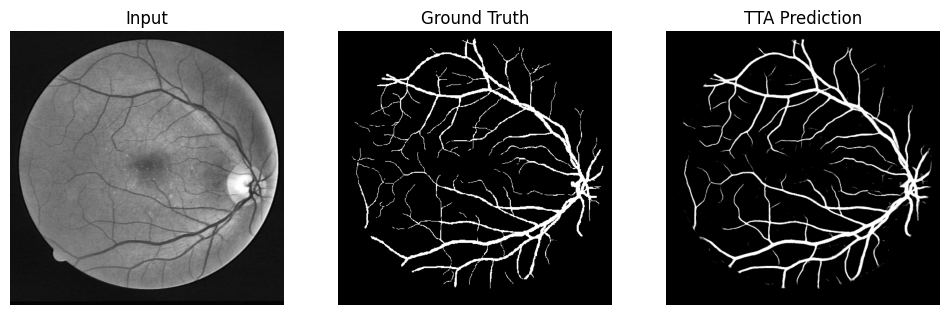

In [106]:
image, mask = next(iter(val_loader))
image = image.to(device)

with torch.no_grad():
    pred = tta_predict(model, image)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(image[0].permute(1,2,0).cpu())
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask[0][0], cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred[0][0].cpu(), cmap="gray")
plt.axis("off")

plt.show()